# Practical 1 — Generative and Discriminative Models

**Enrollment:** BT24S05F007

## Aim
Study Generative AI by training two different models on the same handwritten digits, then compare what each one can do.

## What the two models answer
A **discriminative** model answers: given this picture, which digit is it? It estimates `P(digit | pixels)`.

A **generative** model answers: what do pictures of this digit look like? It estimates `P(pixels | digit)`. Because it stores that pattern, it can invent a new picture, not only label one.

## Data
MNIST digits: 28×28 grayscale images, labels 0 to 9. A fixed subset of 5,000 images keeps the run short. Pixel values are scaled to the range 0–1.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 24
rng = np.random.default_rng(RANDOM_STATE)

mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
images = mnist.data.astype(np.float64) / 255.0
digits = mnist.target.astype(int)

chosen = rng.choice(len(images), size=5000, replace=False)
images = images[chosen]
digits = digits[chosen]

print("Subset shape (images, pixels):", images.shape)
print("Count of each digit:", np.bincount(digits))


Subset shape (images, pixels): (5000, 784)
Count of each digit: [510 540 512 520 456 449 486 557 486 484]


## A look at real digits
One example of each digit from the subset. These are the pictures both models will learn from.


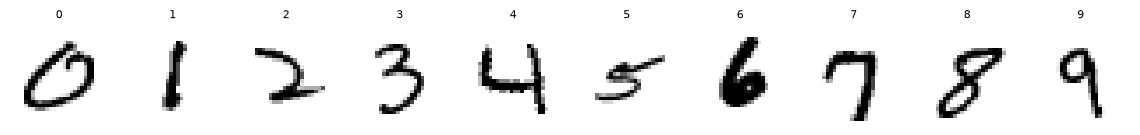

In [2]:
def show_row(pictures, captions):
    fig, axes = plt.subplots(1, len(pictures), figsize=(len(pictures) * 1.15, 1.6))
    for ax, picture, caption in zip(axes, pictures, captions):
        ax.imshow(picture.reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
        ax.set_title(caption, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

examples = []
example_titles = []
for digit in range(10):
    examples.append(images[digits == digit][0])
    example_titles.append(str(digit))

show_row(examples, example_titles)


## Discriminative model
Logistic regression, trained with stochastic gradient descent, reads the 784 pixel values and returns a digit. It never builds a picture. Its only job is the decision.


Discriminative accuracy on held-out digits: 0.861
Confusion matrix (row = true digit, column = predicted digit):
[[120   1   2   0   0   3   1   1   0   0]
 [  0 130   0   0   0   2   1   0   2   0]
 [  2   1 117   1   1   0   0   2   4   0]
 [  1   1   4 104   0   8   1   5   4   2]
 [  0   1   1   0 101   4   1   1   0   5]
 [  2   3   1   4   2  92   4   0   1   3]
 [  1   0   2   1   5   5 107   1   0   0]
 [  2   1   1   2   0   0   0 126   1   6]
 [  3   5   2   3   2   8   1   5  87   5]
 [  1   2   1   2   7   4   0  11   1  92]]


/private/tmp/genai-lab/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


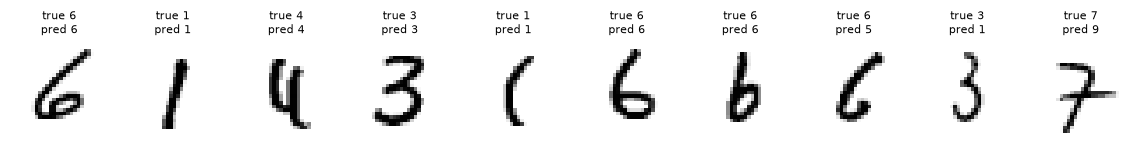

In [3]:
train_x, test_x, train_y, test_y = train_test_split(
    images,
    digits,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=digits,
)

digit_reader = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    max_iter=50,
    random_state=RANDOM_STATE,
)
digit_reader.fit(train_x, train_y)
reader_guess = digit_reader.predict(test_x)
reader_accuracy = accuracy_score(test_y, reader_guess)

print(f"Discriminative accuracy on held-out digits: {reader_accuracy:.3f}")
print("Confusion matrix (row = true digit, column = predicted digit):")
print(confusion_matrix(test_y, reader_guess))

preview = test_x[:10]
preview_titles = [
    f"true {true}\npred {pred}"
    for true, pred in zip(test_y[:10], reader_guess[:10])
]
show_row(preview, preview_titles)


## Generative model
A Gaussian Naive Bayes model keeps, for every digit, the average brightness of each pixel and how much that brightness varies. That pair of numbers is a simple description of "what a 4 looks like".

The same description can be used in two directions:
- **classify** a picture by asking which digit's pattern it matches
- **draw** a new picture by sampling pixel values from that pattern


Generative-model accuracy on the same test set: 0.544
Learned average image of each digit:


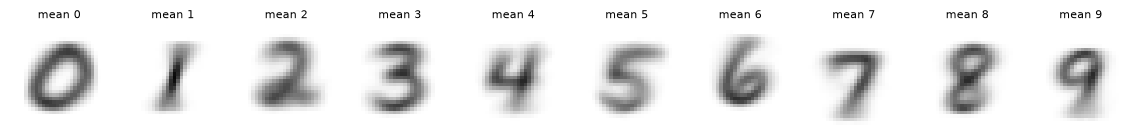

In [4]:
digit_painter = GaussianNB()
digit_painter.fit(train_x, train_y)
painter_guess = digit_painter.predict(test_x)
painter_accuracy = accuracy_score(test_y, painter_guess)

print(f"Generative-model accuracy on the same test set: {painter_accuracy:.3f}")
print("Learned average image of each digit:")
show_row(np.clip(digit_painter.theta_, 0, 1), [f"mean {d}" for d in range(10)])


## Drawing new digits
Sampling adds noise, scaled by the learned pixel variance, onto the class average, then clips the result back to a valid image. These pictures were not in the dataset.


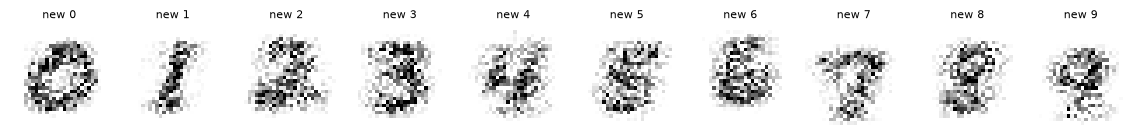

In [5]:
def draw_digit(model, digit):
    average = model.theta_[digit]
    spread = np.sqrt(model.var_[digit])
    noisy = average + rng.normal(0.0, 1.0, size=average.shape) * spread
    return np.clip(noisy, 0.0, 1.0)

drawn = [draw_digit(digit_painter, digit) for digit in range(10)]
show_row(drawn, [f"new {d}" for d in range(10)])


## Reconstructing a test image
Reconstruction asks a different question from classification: how close can the model come to the original picture?

Two reconstructions are compared on the same test images:
1. **Class average** — replace the picture with the generative model's average for the predicted digit.
2. **PCA** — compress the picture to 30 numbers and expand it back. This keeps the shared shape of digits and drops fine detail.


Class-average reconstruction error (MSE): 0.0601
PCA reconstruction error (MSE):          0.0170
Share of variance kept by 30 components: 0.735
Original, class-average reconstruction, PCA reconstruction:


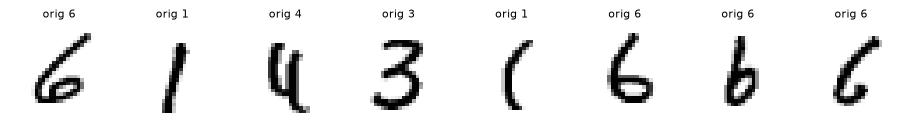

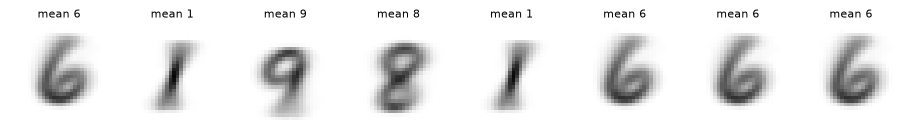

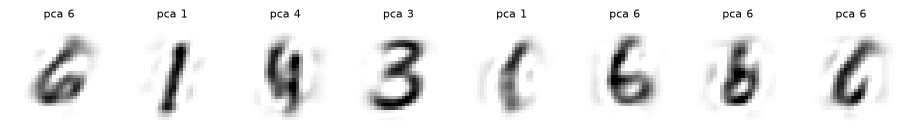

In [6]:
class_average = np.clip(digit_painter.theta_[painter_guess], 0, 1)
class_average_error = np.mean((test_x - class_average) ** 2)

compressor = PCA(n_components=30, random_state=RANDOM_STATE)
compressor.fit(train_x)
compressed = np.clip(compressor.inverse_transform(compressor.transform(test_x)), 0, 1)
pca_error = np.mean((test_x - compressed) ** 2)
variance_kept = compressor.explained_variance_ratio_.sum()

print(f"Class-average reconstruction error (MSE): {class_average_error:.4f}")
print(f"PCA reconstruction error (MSE):          {pca_error:.4f}")
print(f"Share of variance kept by 30 components: {variance_kept:.3f}")

print("Original, class-average reconstruction, PCA reconstruction:")
show_row(test_x[:8], [f"orig {d}" for d in test_y[:8]])
show_row(class_average[:8], [f"mean {d}" for d in painter_guess[:8]])
show_row(compressed[:8], [f"pca {d}" for d in test_y[:8]])


## Comparison


In [7]:
print("Task                         Discriminative        Generative")
print("---------------------------  --------------------  ----------------------")
print(f"Decide the digit             accuracy {reader_accuracy:.3f}         accuracy {painter_accuracy:.3f}")
print("Invent a new digit image     not supported         samples from class stats")
print(f"Rebuild a test image         not the training goal MSE {class_average_error:.4f} (class mean)")
print(f"Compact reconstruction       PCA MSE {pca_error:.4f}       (shared by both views of the data)")


Task                         Discriminative        Generative
---------------------------  --------------------  ----------------------
Decide the digit             accuracy 0.861         accuracy 0.544
Invent a new digit image     not supported         samples from class stats
Rebuild a test image         not the training goal MSE 0.0601 (class mean)
Compact reconstruction       PCA MSE 0.0170       (shared by both views of the data)


## Conclusion
The discriminative model only separates the ten classes, so a higher classification score does not mean it can draw. The generative model stores a pixel pattern for each digit, which is why the same fit can label an image and also sample a new one. Its class-average reconstruction is blurrier than PCA, because a single average cannot show every way people write a digit. That gap is the reason later practicals move from simple probability models to GANs and diffusion models.


## Run results

These are the values and figures produced when the notebook was executed.

```
Subset shape (images, pixels): (5000, 784)
Count of each digit: [510 540 512 520 456 449 486 557 486 484]
```

```
Discriminative accuracy on held-out digits: 0.861
Confusion matrix (row = true digit, column = predicted digit):
[[120   1   2   0   0   3   1   1   0   0]
 [  0 130   0   0   0   2   1   0   2   0]
 [  2   1 117   1   1   0   0   2   4   0]
 [  1   1   4 104   0   8   1   5   4   2]
 [  0   1   1   0 101   4   1   1   0   5]
 [  2   3   1   4   2  92   4   0   1   3]
 [  1   0   2   1   5   5 107   1   0   0]
 [  2   1   1   2   0   0   0 126   1   6]
 [  3   5   2   3   2   8   1   5  87   5]
 [  1   2   1   2   7   4   0  11   1  92]]
```

```
Generative-model accuracy on the same test set: 0.544
Learned average image of each digit:
```

```
Class-average reconstruction error (MSE): 0.0601
PCA reconstruction error (MSE):          0.0170
Share of variance kept by 30 components: 0.735
Original, class-average reconstruction, PCA reconstruction:
```

```
Task                         Discriminative        Generative
---------------------------  --------------------  ----------------------
Decide the digit             accuracy 0.861         accuracy 0.544
Invent a new digit image     not supported         samples from class stats
Rebuild a test image         not the training goal MSE 0.0601 (class mean)
Compact reconstruction       PCA MSE 0.0170       (shared by both views of the data)
```

**real digits**

![real digits](results/GenAI_Practical_01_real_digits.png)

**classifier preview**

![classifier preview](results/GenAI_Practical_01_classifier_preview.png)

**class averages**

![class averages](results/GenAI_Practical_01_class_averages.png)

**drawn digits**

![drawn digits](results/GenAI_Practical_01_drawn_digits.png)

**originals**

![originals](results/GenAI_Practical_01_originals.png)

**class mean reconstruction**

![class mean reconstruction](results/GenAI_Practical_01_class_mean_reconstruction.png)

**pca reconstruction**

![pca reconstruction](results/GenAI_Practical_01_pca_reconstruction.png)
